In [1]:
import xarray as xr
import nemo_cookbook as nc
import pandas as pd
import numpy as np

from nemo_cookbook import NEMODataTree
from OceanDataStore import OceanDataCatalog

In [2]:
extent = [138,150,-68,-63]
t1 = pd.Timestamp(2002,1,1)
t2 = pd.Timestamp(2022,12,31) 

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.Catalog

<Catalog id=noc-model-stac>

In [6]:
catalog.search(collection='noc-npd-era5',variable_name='vo')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/V1y
              Title: eORCA1 ERA5v1 NPD V1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at V-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/I1y
              Title: eORCA1 ERA5v1 NPD I1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global se

In [12]:
itemid4 = 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_4d'
itemid3 = 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d'

In [ ]:
ds4 = catalog.open_dataset(id=itemid4,
                           variable_names=['thetao_con','so_abs'],
                          )
               
ds3 = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',
                           variable_names=['zos'])

  2025-11-21T09:50:39.042757Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: error trying to connect: HTTP connect timeout occurred after 1s: HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.5.18/src/imds/region.rs:66

  2025-11-21T09:50:40.622155Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: error trying to connect: HTTP connect timeout occurred after 1s: HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorErr

In [33]:
ds = xr.merge([ds4,ds3])

/tmp/ipykernel_1071212/4041460091.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds4,ds3])
/tmp/ipykernel_1071212/4041460091.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds4,ds3])
/tmp/ipykernel_1071212/4041460091.py:1: FutureWarning: In a future version of xarray the default value for compat 

In [39]:
lats = ds.nav_lat.load()
lons = ds.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])

In [50]:
dsc=ds.where(mask,drop=True).sel(time_counter=slice(t1,t2))

In [51]:
dsc = dsc.resample({'time_counter':'MS'}).mean()

In [54]:
dsc.load()

<xarray.Dataset> Size: 3GB
Dimensions:       (time_counter: 252, deptht: 75, y: 146, x: 145)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2002-01-01 ... 2022-12-01
  * deptht        (deptht) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
  * y             (y) int64 1kB 915 916 917 918 919 ... 1056 1057 1058 1059 1060
  * x             (x) int64 1kB 780 781 782 783 784 785 ... 920 921 922 923 924
    nav_lon       (y, x) float64 169kB 138.0 138.1 138.2 ... 149.8 149.9 150.0
    nav_lat       (y, x) float64 169kB -67.99 -67.99 -67.99 ... -63.0 -63.0
Data variables:
    thetao_con    (time_counter, deptht, y, x) float32 2GB nan nan ... nan nan
    so_abs        (time_counter, deptht, y, x) float32 2GB nan nan ... nan nan
    zos           (time_counter, y, x) float32 21MB nan nan ... -1.695 -1.699
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Jul-22 16:19:04 GMT
    uuid:         61cea34a-0d4b-42be-bb07-aebe2e46e60f

In [55]:
zos_avg = dsc.zos.mean(['x','y'])
zos_cmt = zos_avg.groupby('time_counter.month').mean()
zos_snm = zos_avg.groupby('time_counter.month') - zos_cmt

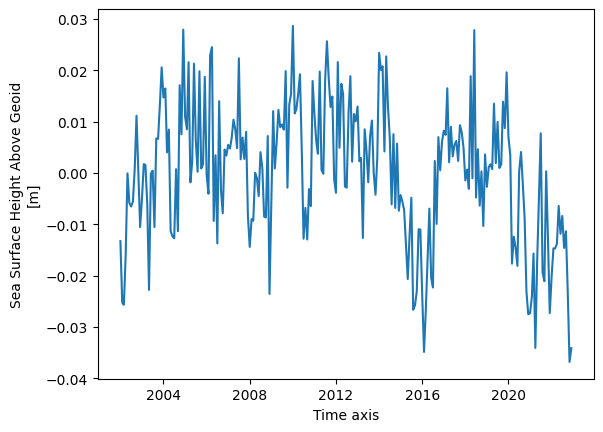

In [56]:
zos_snm.plot()

In [2]:
base_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1"

# Opening domain_cfg:
ds_domain = (xr.open_zarr(f"{base_url}/domain/domain_cfg", consolidated=True, chunks={})
             .squeeze(drop=True)
             .rename({"z": "nav_lev"})
             )

# Opening gridT dataset, including sea surface temperature (°C) and salinity (g kg-1):
ds_gridT = xr.merge([xr.open_zarr(f"{base_url}/T1m/{var}", consolidated=True, chunks={})[var] for var in ['tos_con', 'sos_abs']], compat="override")

In [4]:
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT}}

nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F")

nemo

<xarray.DataTree>
Group: /
│   Dimensions:        (time_counter: 577)
│   Coordinates:
│     * time_counter   (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:00 ... ...
│       time_centered  (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:        (time_counter: 577, j: 331, i: 360, k: 75)
│       Coordinates:
│         * j              (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i              (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
│         * k              (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           time_centered  (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│           gphit          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Data variables:
│           tos_con        (time_counter, j, i) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           sos_abs        (time_counter, j, i) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           e1t            (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t            (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           top_level      (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           bottom_level   (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask          (k, j, i) bool 9MB False False False ... False False False
│           tmaskutil      (j, i) bool 119kB False False False ... False False False
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) bool 9MB False False False ... False False False
│           umaskutil     (j, i) bool 119kB False False False ... False False False
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridV
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 328.5 329.5 330.5 331.5
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiv         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamv         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Data variables:
│           e1v           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2v           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           vmask         (k, j, i) bool 9MB False False False ... False False False
│           vmaskutil     (j, i) bool 119kB False False False ... False False False
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridW
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│         * j  

In [6]:
T=xr.open_dataset('/home/users/eejco/.cache/nemo_cookbook/AMM12/AMM12_1d_20120102_20120110_grid_T.nc')

In [7]:
T

<xarray.Dataset> Size: 5MB
Dimensions:               (time_counter: 8, axis_nbounds: 2, y: 224, x: 198)
Coordinates:
  * time_counter          (time_counter) datetime64[ns] 64B 2012-01-02T12:00:...
    nav_lat               (y, x) float32 177kB ...
    nav_lon               (y, x) float32 177kB ...
    time_centered         (time_counter) datetime64[ns] 64B ...
Dimensions without coordinates: axis_nbounds, y, x
Data variables:
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 128B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 128B ...
    tos                   (time_counter, y, x) float32 1MB ...
    sos                   (time_counter, y, x) float32 1MB ...
    zos                   (time_counter, y, x) float32 1MB ...
Attributes:
    name:         AMM12_1d_20120102_20120110_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Sep-13 19:56:20 GMT
    uuid:         028558e4-3cc9-45b5-9f40-8b5fe1f44b58

In [5]:
nemo = NEMODataTree.from_paths(paths, iperio=True, nftype="T")

nemo

<xarray.DataTree>
Group: /
│   Dimensions:               (time_counter: 8, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 64B 2012-01-02T12:00:...
│       time_centered         (time_counter) datetime64[ns] 64B ...
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 128B ...
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 128B ...
│   Attributes:
│       nftype:   T
│       iperio:   True
├── Group: /gridT
│       Dimensions:               (time_counter: 8, axis_nbounds: 2, j: 224, i: 198,
│                                  k: 51)
│       Coordinates:
│         * j                     (j) int64 2kB 1 2 3 4 5 6 ... 219 220 221 222 223 224
│         * i                     (i) int64 2kB 1 2 3 4 5 6 ... 193 194 195 196 197 198
│         * k                     (k) int64 408B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50 51
│           time_centered         (time_counter) datetime64[ns] 64B ...
│           gphit                 (j, i) float64 355kB ...
│           glamt                 (j, i) float64 355kB ...
│       Dimensions without coordinates: axis_nbounds
│       Data variables:
│           time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 128B ...
│           time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 128B ...
│           tos                   (time_counter, j, i) float32 1MB ...
│           sos                   (time_counter, j, i) float32 1MB ...
│           zos                   (time_counter, j, i) float32 1MB ...
│           e1t                   (j, i) float64 355kB ...
│           e2t                   (j, i) float64 355kB ...
│           top_level             (j, i) int32 177kB ...
│           bottom_level          (j, i) int32 177kB ...
│           tmask                 (k, j, i) bool 2MB False False False ... False False
│           tmaskutil             (j, i) bool 44kB False False False ... False False
│       Attributes:
│           nftype:   T
│           iperio:   True
├── Group: /gridU
│       Dimensions:               (time_counter: 8, axis_nbounds: 2, j: 224, i: 198,
│                                  k: 51)
│       Coordinates:
│         * j                     (j) int64 2kB 1 2 3 4 5 6 ... 219 220 221 222 223 224
│         * i                     (i) float64 2kB 1.5 2.5 3.5 4.5 ... 196.5 197.5 198.5
│         * k                     (k) int64 408B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50 51
│           time_centered         (time_counter) datetime64[ns] 64B ...
│           gphiu                 (j, i) float64 355kB ...
│           glamu                 (j, i) float64 355kB ...
│       Dimensions without coordinates: axis_nbounds
│       Data variables:
│           time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 128B ...
│           time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 128B ...
│           uos                   (time_counter, j, i) float32 1MB ...
│           e1u                   (j, i) float64 355kB ...
│           e2u                   (j, i) float64 355kB ...
│           umask                 (k, j, i) bool 2MB False False False ... False False
│           umaskutil             (j, i) bool 44kB False False False ... False False
│       Attributes:
│           name:         AMM12_1d_20120102_20120110_grid_U
│           description:  ocean U grid variables
│           title:        ocean U grid variables
│           Conventions:  CF-1.6
│           timeStamp:    2025-Sep-13 19:56:20 GMT
│           uuid:         ebd4641e-397c-45b2-bf60-0f3f9eea1ef7
│           nftype:       T
│           iperio:       True
├── Group: /gridV
│       Dimensions:               (time_counter: 8, axis_nbounds: 2, j: 224, i: 198,
│                                  k: 51)
│       Coordinates:
│         * j                     (j) float64 2kB 1.5 2.5 3.5 4.5 ... 222.5 223.5 224.5
│         * i  